#**Central Tendency**

**Mean**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [5]:
df['weight'].mean()

np.float64(2970.424623115578)

**Median**


In [6]:
df['horsepower'].median()

93.5

**Mode**

In [7]:
df['origin'].nunique()

3

In [8]:
df['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [9]:
df['origin'].mode()

,origin
0,usa


**Mean and Median** = Numerical Columns

**Mode** = Object, Categorial Data

#**Measure of Dispersion**

**Range**

In [10]:
df['mpg']

range = max(df['mpg']) - min(df['mpg'])
range

37.6

In [11]:
np.ptp(df['mpg'])

np.float64(37.6)

**Variance**

In [12]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [13]:
df.acceleration

,acceleration
0,12.0
1,11.5
2,11.0
3,12.0
4,10.5
...,...
393,15.6
394,24.6
395,11.6
396,18.6


In [14]:
df.acceleration.var()

7.604848233611381

**Standard Deviation**

In [15]:
np.std(df['acceleration'])

2.7542223175940177

**Percentile**

1) Quartile 1 - 25%

2) Quartile 2 - 50%

3) Quartile 3 - 75%

In [16]:
data = [10,30,20,40,50,22,35,67,78,43,92,49]

np.percentile(data,25)

np.float64(28.0)

**Inter quarltile range**

IQR = Q3- Q1

  **Outlier**

In [17]:
age = [ 18, 20,23,25,28,35,39,43,47,52,55,59,65,-10,-13]
len(age)

15

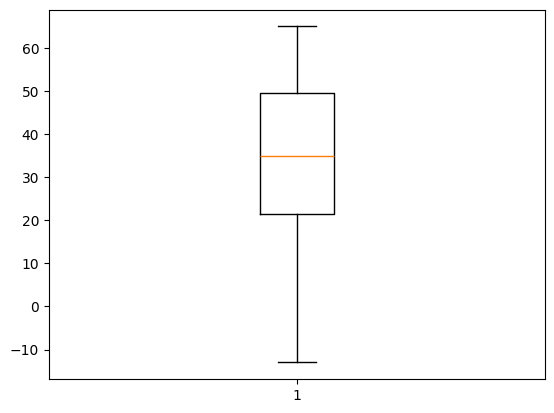

In [18]:
#box plot
plt.boxplot(age)
plt.show()

In [19]:
age = [ 18, 20,23,25,28,35,39,43,47,52,55,59,65,-10,-13]

In [20]:
Q1 = np.percentile(age,25)
Q3 = np.percentile(age,75)

IQR = Q3 - Q1
IQR

np.float64(28.0)

In [21]:
UF = Q3 + (1.5 * IQR)
LF = Q1 - (1.5 * IQR)

print(UF)
print(LF)

91.5
-20.5


In [22]:
x = age.copy()
for i in x:
  if i >= UF or i <= LF:
    print(f'Outlier value is {i} and has been removed')
    age.remove(i)

In [23]:
age

[18, 20, 23, 25, 28, 35, 39, 43, 47, 52, 55, 59, 65, -10, -13]

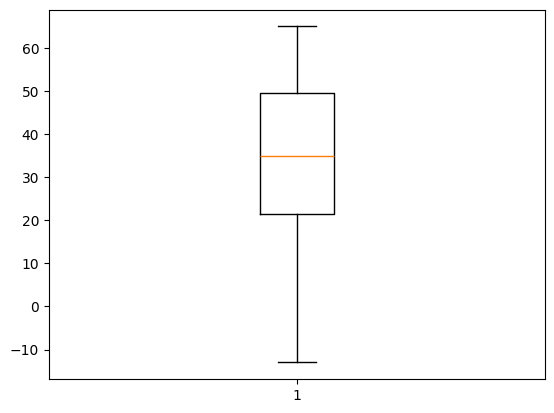

In [24]:
plt.boxplot(age)
plt.show()

**Correlation**

In [25]:
titanic = sns.load_dataset('titanic')

In [26]:
corrMat = titanic.corr(numeric_only=True)
corrMat

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


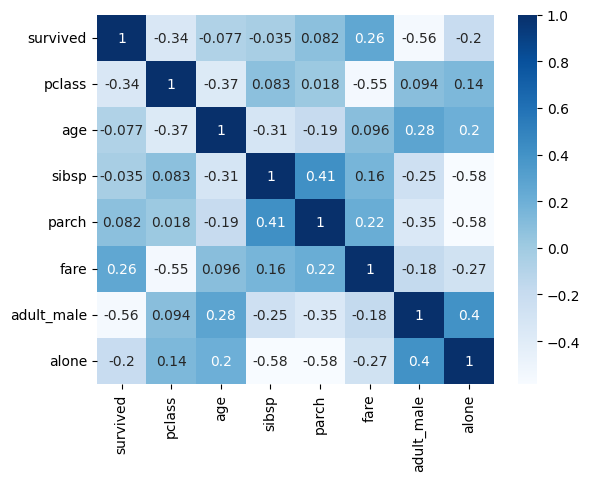

In [27]:
sns.heatmap(corrMat, annot = True, cmap = 'Blues')
plt.show()

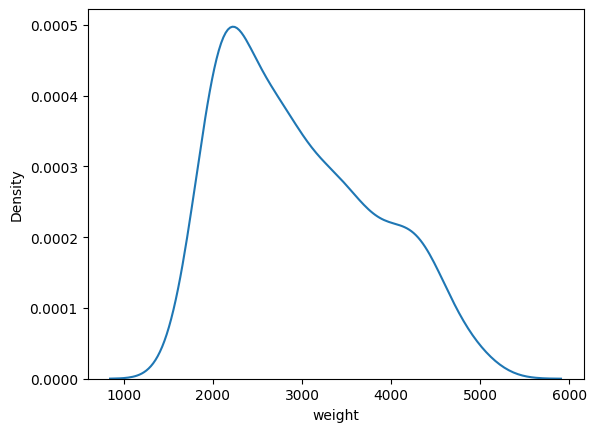

In [28]:
sns.kdeplot(df['weight'])
plt.show()

In [29]:
from scipy.stats import skew

In [30]:
df['weight'].skew()

np.float64(0.5310625125994629)

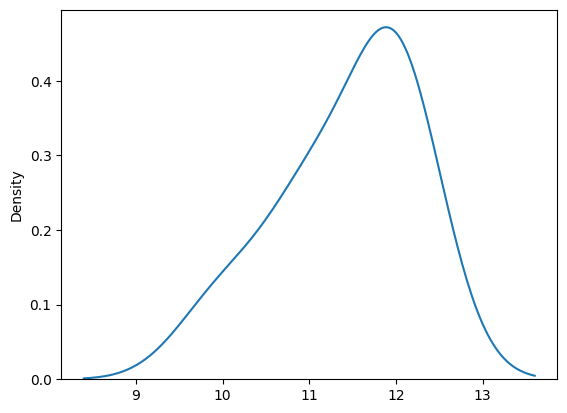

In [31]:
data = [10,11,11,12,12,12,12]
sns.kdeplot(data)
plt.show()

In [32]:
skew(data)

np.float64(-0.8598938232981931)

**Kurtosis**

In [33]:
from scipy.stats import kurtosis

In [34]:
kurtosis(df['weight'])

np.float64(-0.7907326965772179)

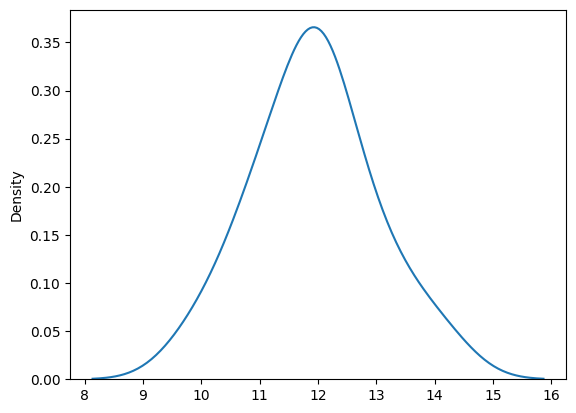

np.float64(-0.10799319727891099)

In [35]:
data = [10,11,11,11,12,12,12,12,12,12,13,13,14]
sns.kdeplot(data)
plt.show()
kurtosis(data)

**Tests**

In [36]:
#small p-value(<0.05) :- Reject the null hypothesis
#large p-value(>0.05) :- Accept the null hypothesis

In [37]:
import seaborn as sns
from scipy import stats

In [38]:
penguins = sns.load_dataset('penguins').dropna()

In [39]:
tstat, pvalue = stats.ttest_1samp(penguins['flipper_length_mm'], popmean = 200)

In [40]:
pvalue

np.float64(0.2089240226905175)

In [41]:
if pvalue <= 0.05:
  print('null hypothesis rejected')
else:
  print('null hypothesis accepted')

null hypothesis accepted


In [42]:
male = penguins[penguins['sex'] == 'Male']['flipper_length_mm']
female = penguins[penguins['sex'] == 'Female']['flipper_length_mm']

t_test, pvalue = stats.ttest_ind(male, female, equal_var = False)

In [43]:
if pvalue <= 0.05:
  print('null hypothesis rejected')
else:
  print('null hypothesis accepted')

null hypothesis rejected


Statement: The avg body mass of male and female peguins are different

In [44]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [45]:
male = penguins[penguins['sex'] == 'Male']['body_mass_g']
female = penguins[penguins['sex'] == 'Female']['body_mass_g']


In [46]:
male

,body_mass_g
0,3750.0
5,3650.0
7,4675.0
13,3800.0
14,4400.0
...,...
333,5500.0
335,5850.0
337,6000.0
341,5750.0


In [47]:
female

,body_mass_g
1,3800.0
2,3250.0
4,3450.0
6,3625.0
12,3200.0
...,...
332,4650.0
334,4375.0
338,4925.0
340,4850.0


In [48]:
np.var(male)

616666.6445223924

In [49]:
np.var(female)

441095.59228650125

In [50]:
t_test, pvalue = stats.ttest_ind(male, female, equal_var = False)

In [51]:
if pvalue <= 0.05:
  print('null hypothesis rejected')
else:
  print('null hypothesis accepted')

null hypothesis rejected


**F Stats, Chi square, ANOVA, Ztest**


In [52]:
A = [25,30,25,35,40]
B = [30,35,40,45,50]

In [53]:
varA, VarB = np.var(A,ddof = 1), np.var(B, ddof = 1)

In [54]:
from scipy.stats import f

In [55]:
f_stat = varA / VarB
df1, df2 = len(A)-1, len(B)-1

In [56]:
f_stat

np.float64(0.68)

In [57]:
p_value = 1 - f.cdf(f_stat, df1, df2)
p_value

np.float64(0.6411294676600798)

In [58]:
if pvalue <= 0.05:
  print('null hypothesis rejected')
else:
  print('null hypothesis accepted')

null hypothesis rejected


**Chi squared test**

In [59]:
data = np.array([[30,10],[25,15]])

In [60]:
from scipy.stats import chi2_contingency

In [61]:
chi2, p, dof, expected = chi2_contingency(data)

In [62]:
chi2, p

(np.float64(0.9309090909090909), np.float64(0.3346268097478841))

**Anova Test**

In [63]:
A = [85,90,88,75,95]
B = [70,65,80,72,68]
C = [88,85,90,92,87]

from scipy.stats import f_oneway

In [64]:
f_stat, p_val = f_oneway(A,B,C)

In [65]:
p_val

np.float64(0.0006253182565830169)

**Z-Test**

In [66]:
from scipy.stats import norm

In [67]:
sample = [72,70,68,65,74,69]
mean_samp = np.mean (sample)
pop_mean = 70
pop_std = 3
n = len(sample)

In [68]:
#Z test
z = (mean_samp - pop_mean) / (pop_std / np.sqrt(n))
z

np.float64(-0.2721655269759048)

In [69]:
pVal = 2*(1-norm.cdf(abs(z)))
z,pVal

(np.float64(-0.2721655269759048), np.float64(0.7854947471183573))

In [72]:
np.mean(sample)

np.float64(69.66666666666667)